# 12 — Mini Trend + Regulation Demand Model (presentation intro)

A deliberately **simple, one-slide** biodiesel demand model, separate from the detailed per-region pipeline. It forecasts the 5 series (**Nacional + Madrid, Cataluña, Andalucía, Valencia**) for **2026-01 → 2027-12**. Regions are never summed; Nacional is the independently reported España total.

## What the target actually measures (read first)
The CORES **"biodiésel"** series (`Consumo_Tm`) counts only **pure biodiesel and labelled blends above ~7% FAME**. Ordinary low-level B7 blending is invisible here — it is reported as Gasóleo A. So this target is **not** total biodiesel and is **not** a direct function of the blending mandate %. It is a **new product segment being rolled out from near-zero**, and its shape is an **adoption curve**.

## The model in one line
- **Trend = the engine.** A saturating growth curve (Logistic / Gompertz, best per series by in-sample fit) fitted to each series' 2023-25 history *is* the forecast.
- **Regulation = direction + guardrail, not a multiplier.** Spain's biofuel obligation rising 11.5% (2025) → 14% (2026, RD 5/2026), and RED III heading to 29% renewable / 14.5% GHG-intensity by 2030, tells us the upward trend is **policy-backed and won't reverse**, and informs the **optimistic** upper bound. The mandate % is **never** multiplied into the forecast.

## Three scenarios (a band, not a point)
- **Conservative** — adoption keeps rising but at a slower pace than the fitted curve (saturates earlier, at a lower level).
- **Central** — the fitted growth curve continues (policy tailwind keeps it on track).
- **Optimistic** — adoption accelerates (RED III + Repsol renewable-diesel station rollout).

All three **still grow**: the rising obligation and the segment's consistent year-on-year growth make a flat or declining path implausible — the scenarios differ on *how fast*, not *whether*.

## 0. Setup

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from pathlib import Path

REPO = Path().resolve().parent
INP  = REPO / 'data' / 'inputs'
OUT  = REPO / 'data' / 'outputs'

NAME = {'ESPAÑA': 'Nacional', 'Madrid, Comunidad de': 'Madrid', 'Cataluña': 'Cataluña',
        'Andalucía': 'Andalucía', 'Comunitat Valenciana': 'Valencia'}
SERIES = ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']
COLORS = {'Nacional': '#FF6B35', 'Madrid': '#004E89', 'Cataluña': '#1A936F',
          'Andalucía': '#C84B31', 'Valencia': '#8E44AD'}

m = pd.read_csv(INP / 'master_dataset.csv')
m = m[m['CCAA'].isin(NAME)].copy()
m['Serie'] = m['CCAA'].map(NAME)
m = m.sort_values(['Serie', 'Fecha'])
print('master_dataset:', m['Fecha'].min(), '->', m['Fecha'].max(), '| series:', SERIES)
print('months per series:', m.groupby('Serie').size().unique())

# Saturating growth curves (no linear trend term -> avoids exponential blow-up on log scale)
def f_logistic(t, L, k, t0): return L / (1 + np.exp(-k * (t - t0)))
def f_gompertz(t, L, b, k):  return L * np.exp(-b * np.exp(-k * t))

def fit_curve(t, y, mes, kind):
    ymax = float(np.max(y))
    if kind == 'Logistic':
        popt, _ = curve_fit(f_logistic, t, y, p0=[ymax * 3, 0.3, float(np.median(t))],
                            bounds=([ymax * 1.01, 0.01, t.min() - 24], [ymax * 60, 3.0, t.max() + 60]), maxfev=20000)
        tp = f_logistic(t, *popt)
    else:
        popt, _ = curve_fit(f_gompertz, t, y, p0=[ymax * 3, 5.0, 0.15],
                            bounds=([ymax * 1.01, 0.1, 0.001], [ymax * 60, 200.0, 2.0]), maxfev=20000)
        tp = f_gompertz(t, *popt)
    s = np.sin(2 * np.pi * mes / 12); c = np.cos(2 * np.pi * mes / 12)
    seas_coef, _, _, _ = np.linalg.lstsq(np.column_stack([s, c, np.ones_like(s)]), y - tp, rcond=None)
    return popt, seas_coef

def trend_of(kind, popt, t): return f_logistic(t, *popt) if kind == 'Logistic' else f_gompertz(t, *popt)
def seas_of(coef, mes):
    return coef[0] * np.sin(2 * np.pi * mes / 12) + coef[1] * np.cos(2 * np.pi * mes / 12) + coef[2]
print('Helpers ready.')

master_dataset: 2023-01 -> 2025-12 | series: ['Nacional', 'Madrid', 'Cataluña', 'Andalucía', 'Valencia']
months per series: [36]
Helpers ready.


## 1. Fit the growth curve (the engine)

For each series we fit **both** a Logistic and a Gompertz curve to the 2023-25 history (plus a small sin/cos seasonal correction) and keep whichever fits the history better (higher in-sample R²). No price features; no linear trend term.

In [2]:
MODELS = {}
rows = []
for s in SERIES:
    d = m[m['Serie'] == s]
    y = d['Consumo_Tm'].values.astype(float)
    t = np.arange(1, len(y) + 1)
    mes = d['Fecha'].str[5:7].astype(int).values
    best = None
    for kind in ['Logistic', 'Gompertz']:
        try:
            popt, coef = fit_curve(t, y, mes, kind)
            fitv = np.maximum(trend_of(kind, popt, t) + seas_of(coef, mes), 0)
            sst = np.sum((y - y.mean()) ** 2)
            r2 = 1 - np.sum((y - fitv) ** 2) / sst
            if best is None or r2 > best['r2']:
                best = {'kind': kind, 'popt': popt, 'coef': coef, 'r2': r2}
        except Exception as e:
            print('  {} {} failed: {}'.format(s, kind, e))
    MODELS[s] = best
    rows.append({'Serie': s, 'Chosen_curve': best['kind'], 'InSample_R2': round(best['r2'], 3),
                 '2025_actual_Tm': round(float(y[-12:].sum()))})
print(pd.DataFrame(rows).to_string(index=False))

    Serie Chosen_curve  InSample_R2  2025_actual_Tm
 Nacional     Gompertz        0.956          219662
   Madrid     Gompertz        0.947           32562
 Cataluña     Gompertz        0.959           34465
Andalucía     Gompertz        0.905           17776
 Valencia     Gompertz        0.940           10784


## 2. Build the three scenarios

The forecast trend is the fitted curve. Let `L0` be the fitted trend level at the last history month (Dec-2025) and `g(h) = curve(h) − L0` be the curve's projected growth beyond today. Scenarios are an explicit **pace factor** on that growth (seasonality added equally to all):

| Scenario | Pace factor on growth `g(h)` | Meaning |
|---|---|---|
| Conservative | 0.5 | adoption keeps rising but at half the fitted pace (earlier, lower saturation) |
| Central | 1.0 | the fitted growth curve continues (policy-backed) |
| Optimistic | 1.5 | adoption accelerates above the fitted pace (RED III + Repsol rollout) |

All three pace factors are **positive**, so demand keeps growing in every scenario — consistent with the rising obligation and the segment's track record. **Regulation enters only as justification** (why the trend is durable and why the optimistic upside is credible) — the mandate % is never multiplied in.

In [3]:
SCEN = {'Conservative': 0.5, 'Central': 1.0, 'Optimistic': 1.5}
fcast = pd.date_range('2026-01', periods=24, freq='MS')
tf = np.arange(37, 37 + 24)
mesf = fcast.month.values

rows = []
for s in SERIES:
    md = MODELS[s]
    L0 = trend_of(md['kind'], md['popt'], 36.0)          # fitted level at Dec-2025
    growth = trend_of(md['kind'], md['popt'], tf) - L0    # projected growth beyond today
    season = seas_of(md['coef'], mesf)
    for sc, pace in SCEN.items():
        vals = np.maximum(L0 + pace * growth + season, 0)
        for date, v in zip(fcast, vals):
            rows.append({'Fecha': date.strftime('%Y-%m'), 'Serie': s, 'Scenario': sc, 'Forecast_Tm': round(float(v), 1)})
FC = pd.DataFrame(rows)
FC['Year'] = FC['Fecha'].str[:4]

annual = FC.pivot_table(index=['Serie', 'Year'], columns='Scenario', values='Forecast_Tm', aggfunc='sum').round(0)
annual = annual[['Conservative', 'Central', 'Optimistic']].reindex(SERIES, level=0)
print('Annual biodiesel demand forecast (Tm):')
print(annual.to_string())

Annual biodiesel demand forecast (Tm):
Scenario        Conservative   Central  Optimistic
Serie     Year                                    
Nacional  2026      291084.0  305640.0    320197.0
          2027      302489.0  328451.0    354413.0
Madrid    2026       42605.0   44232.0     45859.0
          2027       43644.0   46309.0     48974.0
Cataluña  2026       43536.0   44809.0     46082.0
          2027       44282.0   46301.0     48320.0
Andalucía 2026       26867.0   29237.0     31607.0
          2027       29188.0   33879.0     38570.0
Valencia  2026       16186.0   17656.0     19128.0
          2027       17737.0   20760.0     23783.0


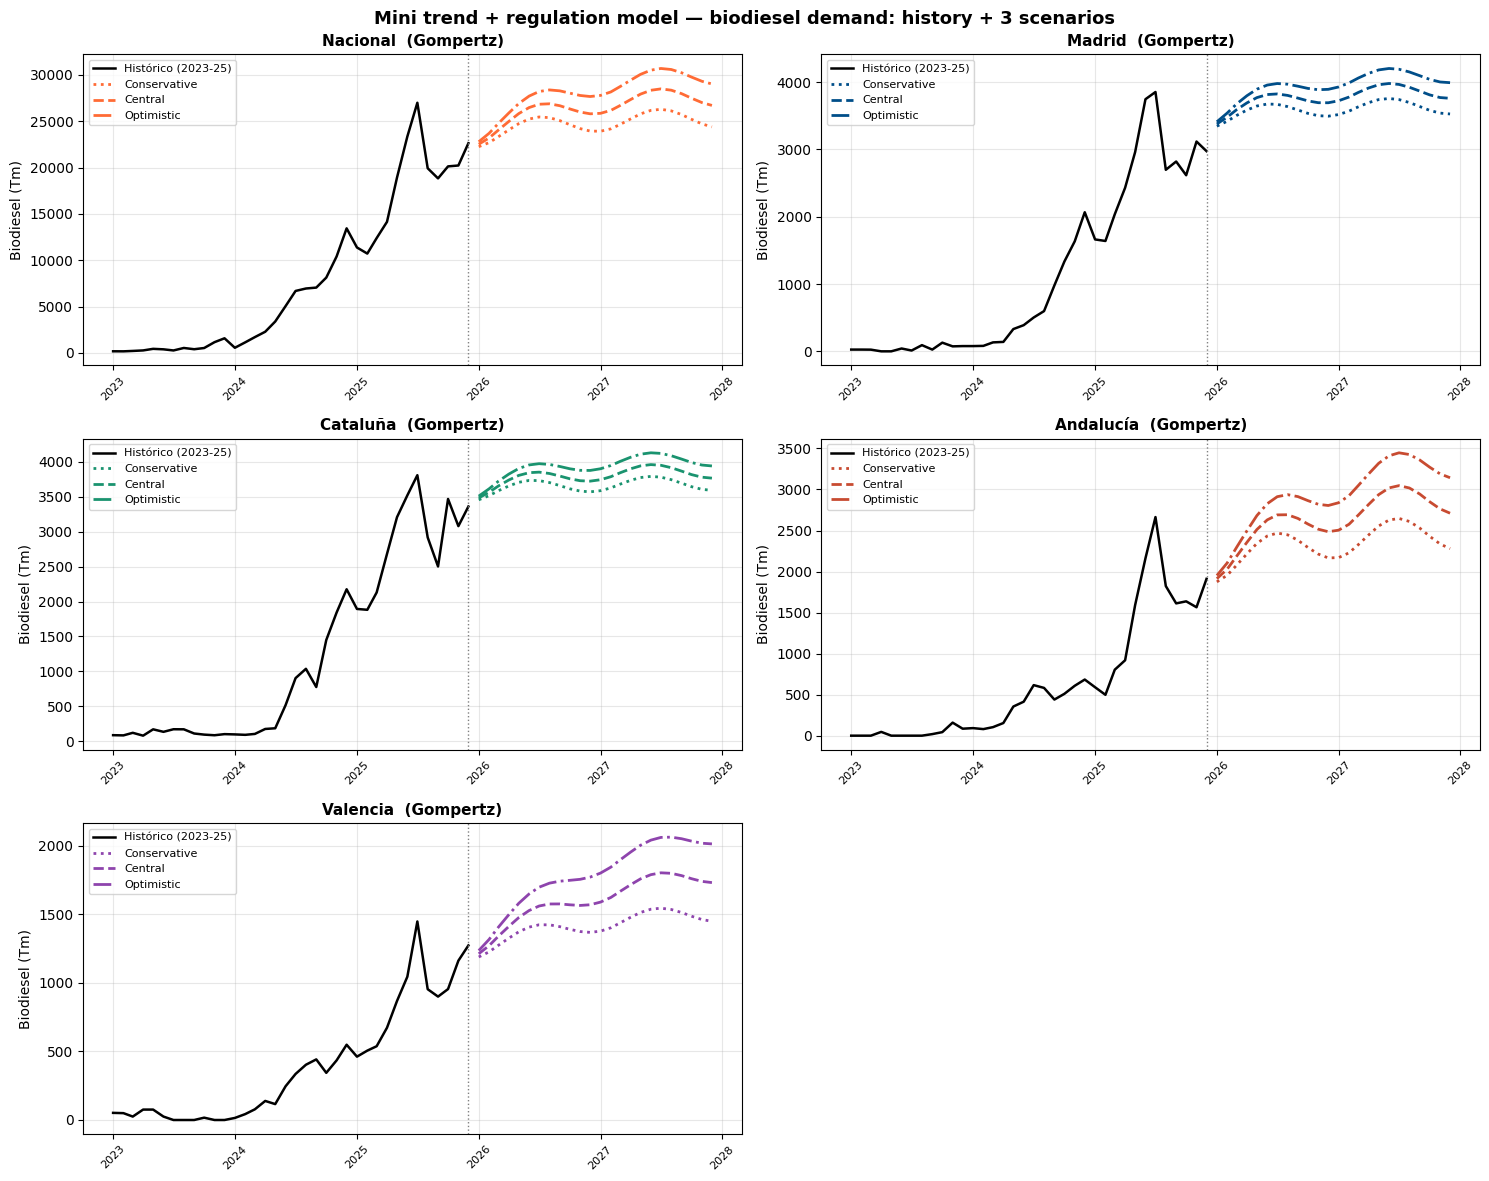

In [4]:
# Combined figure: history (2023-25) + 3 scenario lines (2026-27)
fig, axes = plt.subplots(3, 2, figsize=(15, 12)); axes = axes.ravel()
styles = {'Conservative': ':', 'Central': '--', 'Optimistic': '-.'}
cut = pd.to_datetime('2025-12')
for i, s in enumerate(SERIES):
    ax = axes[i]
    h = m[m['Serie'] == s].copy(); h['date'] = pd.to_datetime(h['Fecha'])
    ax.plot(h['date'], h['Consumo_Tm'], '-', color='black', lw=1.8, label='Histórico (2023-25)')
    for sc in ['Conservative', 'Central', 'Optimistic']:
        f = FC[(FC['Serie'] == s) & (FC['Scenario'] == sc)].copy(); f['date'] = pd.to_datetime(f['Fecha'])
        ax.plot(f['date'], f['Forecast_Tm'], styles[sc], color=COLORS[s], lw=2, label=sc)
    ax.axvline(cut, color='grey', ls=':', lw=1)
    ax.set_title('{}  ({})'.format(s, MODELS[s]['kind']), fontsize=11, weight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=8); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_ylabel('Biodiesel (Tm)')
axes[-1].axis('off')
fig.suptitle('Mini trend + regulation model — biodiesel demand: history + 3 scenarios', fontsize=13, weight='bold')
fig.tight_layout(); plt.show()

In [5]:
# Save scenario forecasts
out_path = OUT / 'mini_model_scenarios.csv'
FC[['Fecha', 'Serie', 'Scenario', 'Forecast_Tm']].to_csv(out_path, index=False)
print('Saved {} rows -> {}'.format(len(FC), out_path))
print(FC[['Fecha', 'Serie', 'Scenario', 'Forecast_Tm']].head(9).to_string(index=False))

Saved 360 rows -> /Users/enricogasparelli/Desktop/Capstone/repsol-capstone/data/outputs/mini_model_scenarios.csv
  Fecha    Serie     Scenario  Forecast_Tm
2026-01 Nacional Conservative      22260.3
2026-02 Nacional Conservative      22696.3
2026-03 Nacional Conservative      23336.3
2026-04 Nacional Conservative      24068.4
2026-05 Nacional Conservative      24750.0
2026-06 Nacional Conservative      25246.4
2026-07 Nacional Conservative      25467.7
2026-08 Nacional Conservative      25393.0
2026-09 Nacional Conservative      25076.6


## Summary (plain language)

- **What the target is:** the CORES *biodiésel* series counts **pure biodiesel + labelled high-FAME blends only** — a new product segment rolled out from near-zero. It is **not** total biodiesel and **not** a function of the blend mandate %.
- **Why a growth curve:** because that roll-out is an **adoption (S-shaped) curve**. A saturating Logistic/Gompertz captures the rapid take-off and eventual levelling-off; a linear/exponential trend would blow up. The curve is fitted to history and *is* the forecast.
- **How regulation is used:** as **direction and guardrail, not a multiplier**. The legislated rise to 14% (2026) and RED III's 2030 targets explain why the adoption trend is policy-backed (won't reverse) and justify the optimistic upside. We deliberately do **not** scale demand by the mandate %, because the target only captures the high-FAME segment, not mandate-driven low-level blending.
- **Output:** three growing scenarios (slower / fitted / accelerated adoption) per series, saved to `data/outputs/mini_model_scenarios.csv`.

### Honest caveats
- Only 36 months of history; the curve's eventual ceiling is uncertain, so 2027 in particular is a wide band (and 2027 is a genuine **policy gap** — the draft RD moves to GHG-intensity targets, not yet enacted).
- The scenario pace factors (0.5×, 1×, 1.5×) are explicit, illustrative assumptions, not estimated probabilities.
- This intro model is for framing; the detailed per-region model (`notebooks/10_final_models.ipynb`) remains the technical forecast.